In [1]:
!pip install spacy nltk pandas textblob matplotlib seaborn pdfplumber wordcloud
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 18.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 25.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import re
import nltk
import spacy
import pdfplumber
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from textblob import TextBlob
from wordcloud import WordCloud


In [3]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
nlp = spacy.load("en_core_web_sm")


In [27]:
from google.colab import files

def extract_text_from_pdf(file_path):
    text = ""
    try:
        with pdfplumber.open(file_path) as pdf:
            for page in pdf.pages:
                text += page.extract_text() + " "
    except Exception as e:
        print(f"Error extracting text from PDF: {e}")
        return ""
    return text

print("Please upload your PDF file(s):")
uploaded = files.upload()

if uploaded:
    # Assuming the user uploads only one PDF file for this task
    filename = next(iter(uploaded))
    print(f"Uploaded file: {filename}")
    raw_text = extract_text_from_pdf(filename)
    print("Preview of extracted text (first 500 characters):")
    print(raw_text[:500])
else:
    print("No file was uploaded.")
    raw_text = ""

Please upload your PDF file(s):


Saving customer_support_tickets.pdf to customer_support_tickets.pdf
Uploaded file: customer_support_tickets.pdf
Preview of extracted text (first 500 characters):
Ticket 1:
Subject: Login Issue
Hi Support Team,
I am unable to login to my account since yesterday. It shows error code 504. Please resolve this
issue urgently.
Thanks,
Arun
Ticket 2:
Subject: Payment Failure
Hello,
My payment was deducted but the subscription is not activated. Transaction ID: TXN45892. Kindly
check.
Regards,
Meena
Ticket 3:
Subject: Password Reset Not Working
Dear Team,
I tried resetting my password but did not receive the reset email. My registered email is
user@example.com.
T


In [28]:
print("Total characters:", len(raw_text))
print("Total lines:", raw_text.count("\n"))
print("Total words:", len(raw_text.split()))


Total characters: 670
Total lines: 26
Total words: 109


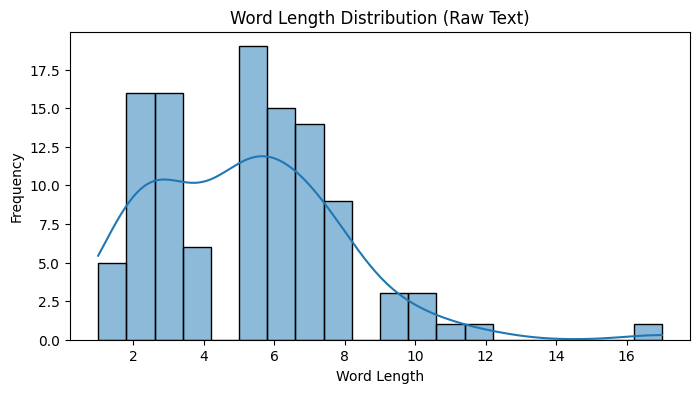

In [29]:
word_lengths = [len(word) for word in raw_text.split()]
plt.figure(figsize=(8,4))
sns.histplot(word_lengths, bins=20, kde=True)
plt.title("Word Length Distribution (Raw Text)")
plt.xlabel("Word Length")
plt.ylabel("Frequency")
plt.show()


In [30]:
def clean_text(text):
    text = text.lower()                      # standardization
    text = re.sub(r'\S+@\S+', '', text)      # remove emails
    text = re.sub(r'http\S+', '', text)      # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)     # remove special characters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

cleaned_text = clean_text(raw_text)
cleaned_text[:300]


'ticket subject login issue hi support team i am unable to login to my account since yesterday it shows error code please resolve this issue urgently thanks arun ticket subject payment failure hello my payment was deducted but the subscription is not activated transaction id txn kindly check regards '

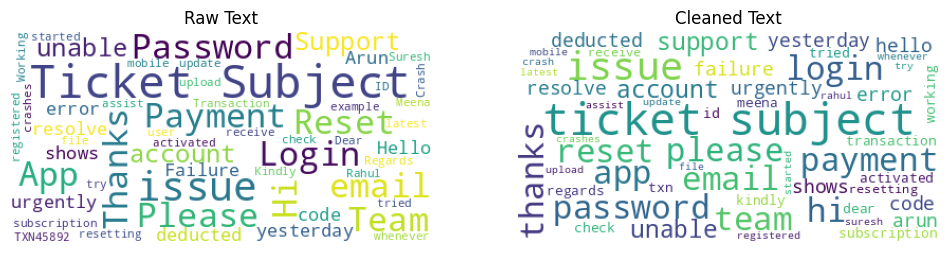

In [31]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
WordCloud(background_color="white").generate(raw_text)
plt.imshow(WordCloud(background_color="white").generate(raw_text))
plt.axis("off")
plt.title("Raw Text")

plt.subplot(1,2,2)
plt.imshow(WordCloud(background_color="white").generate(cleaned_text))
plt.axis("off")
plt.title("Cleaned Text")

plt.show()


In [32]:
nltk.download('punkt_tab')
tokens = word_tokenize(cleaned_text)
tokens[:20]

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['ticket',
 'subject',
 'login',
 'issue',
 'hi',
 'support',
 'team',
 'i',
 'am',
 'unable',
 'to',
 'login',
 'to',
 'my',
 'account',
 'since',
 'yesterday',
 'it',
 'shows',
 'error']

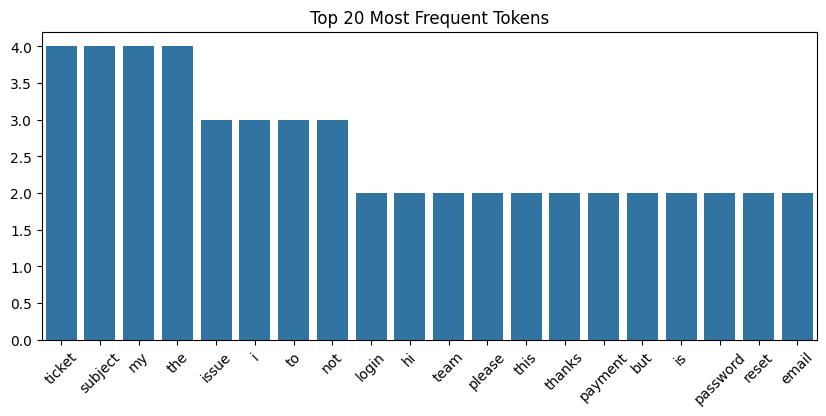

In [33]:
freq_dist = nltk.FreqDist(tokens)
top_words = freq_dist.most_common(20)

words, counts = zip(*top_words)
plt.figure(figsize=(10,4))
sns.barplot(x=list(words), y=list(counts))
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Tokens")
plt.show()


In [34]:
stop_words = set(stopwords.words('english'))
filtered_tokens = [w for w in tokens if w not in stop_words]
filtered_tokens[:20]


['ticket',
 'subject',
 'login',
 'issue',
 'hi',
 'support',
 'team',
 'unable',
 'login',
 'account',
 'since',
 'yesterday',
 'shows',
 'error',
 'code',
 'please',
 'resolve',
 'issue',
 'urgently',
 'thanks']

In [35]:
#stemming
stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(w) for w in filtered_tokens]
stemmed_tokens[:20]


['ticket',
 'subject',
 'login',
 'issu',
 'hi',
 'support',
 'team',
 'unabl',
 'login',
 'account',
 'sinc',
 'yesterday',
 'show',
 'error',
 'code',
 'pleas',
 'resolv',
 'issu',
 'urgent',
 'thank']

In [36]:
#Lemmatization
lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [lemmatizer.lemmatize(w) for w in filtered_tokens]
lemmatized_tokens[:20]


['ticket',
 'subject',
 'login',
 'issue',
 'hi',
 'support',
 'team',
 'unable',
 'login',
 'account',
 'since',
 'yesterday',
 'show',
 'error',
 'code',
 'please',
 'resolve',
 'issue',
 'urgently',
 'thanks']

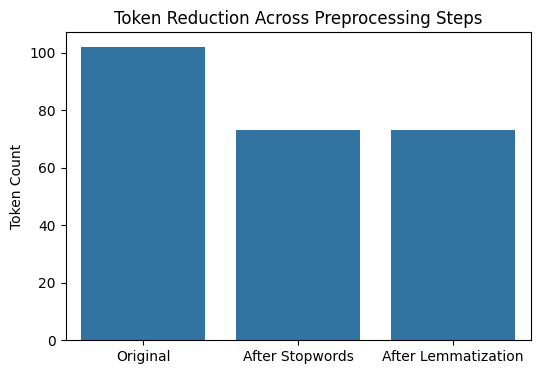

In [37]:
labels = ['Original', 'After Stopwords', 'After Lemmatization']
counts = [len(tokens), len(filtered_tokens), len(lemmatized_tokens)]

plt.figure(figsize=(6,4))
sns.barplot(x=labels, y=counts)
plt.title("Token Reduction Across Preprocessing Steps")
plt.ylabel("Token Count")
plt.show()


In [38]:
corrected_text = str(TextBlob(cleaned_text).correct())
corrected_text[:300]


'ticket subject login issue hi support team i am unable to login to my account since yesterday it shows error code please resolve this issue urgently thanks run ticket subject payment failure hello my payment was deduced but the subscription is not activate transaction id ten kindly check regards bee'

In [39]:
doc = nlp(corrected_text)
entities = [(ent.text, ent.label_) for ent in doc.ents]
entities[:10]


[('yesterday', 'DATE'), ('paul', 'PERSON')]

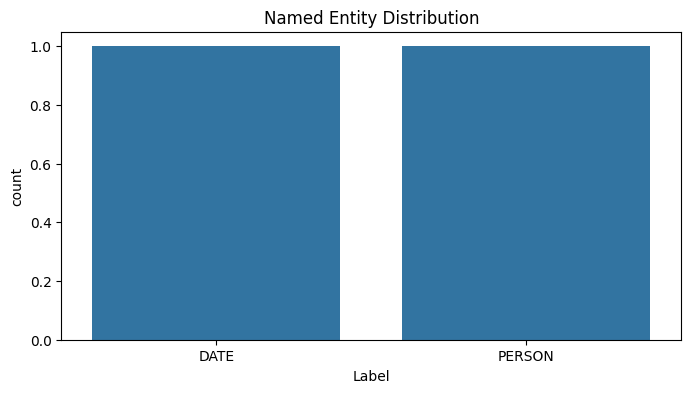

In [40]:
entity_df = pd.DataFrame(entities, columns=["Entity", "Label"])
plt.figure(figsize=(8,4))
sns.countplot(data=entity_df, x="Label")
plt.title("Named Entity Distribution")
plt.show()


In [41]:
final_df = pd.DataFrame({
    "cleaned_text": [cleaned_text],
    "tokens": [lemmatized_tokens],
    "entities": [entities]
})

final_df


,cleaned_text,tokens,entities
0,ticket subject login issue hi support team i a...,"[ticket, subject, login, issue, hi, support, t...","[(yesterday, DATE), (paul, PERSON)]"


In [42]:
final_df.to_csv("cleaned_annotated_tickets.csv", index=False)


/tmp/ipython-input-4207690243.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-4207690243.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


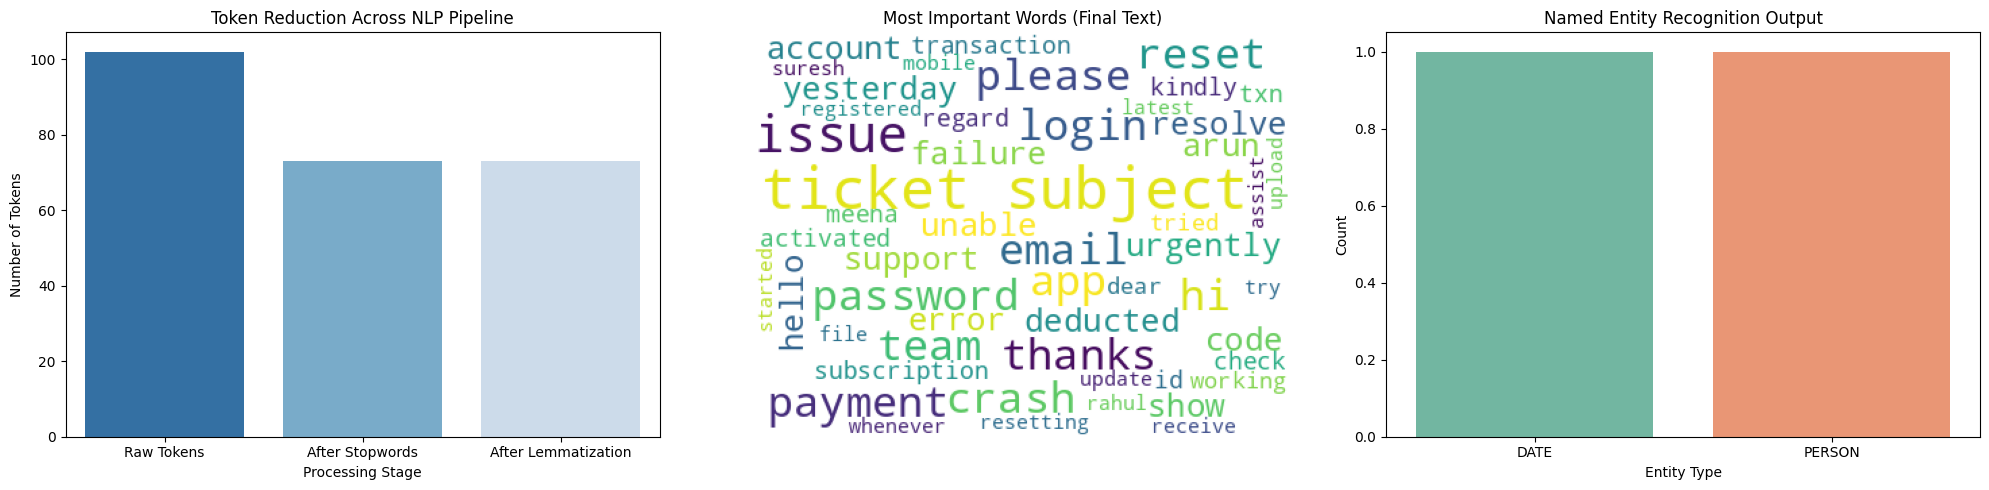

In [43]:
# ---------- FINAL NLP SUMMARY VISUALIZATION ----------

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1️⃣ Token Reduction Bar Chart
stages = ['Raw Tokens', 'After Stopwords', 'After Lemmatization']
token_counts = [len(tokens), len(filtered_tokens), len(lemmatized_tokens)]

sns.barplot(
    x=stages,
    y=token_counts,
    ax=axes[0],
    palette="Blues_r"
)
axes[0].set_title("Token Reduction Across NLP Pipeline")
axes[0].set_ylabel("Number of Tokens")
axes[0].set_xlabel("Processing Stage")

# 2️⃣ Word Cloud (Final Cleaned Text)
wordcloud = WordCloud(
    width=400,
    height=300,
    background_color='white'
).generate(" ".join(lemmatized_tokens))

axes[1].imshow(wordcloud)
axes[1].axis("off")
axes[1].set_title("Most Important Words (Final Text)")

# 3️⃣ Named Entity Distribution
sns.countplot(
    data=entity_df,
    x="Label",
    ax=axes[2],
    palette="Set2"
)
axes[2].set_title("Named Entity Recognition Output")
axes[2].set_xlabel("Entity Type")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()
